# PINN for the Wetterich Equation (Functional Renormalization Group)
## Local Potential Approximation — $d=3$, $N=1$, Litim Regulator

The **Wetterich equation** is the *exact* flow equation for the effective average action $\Gamma_k$:

$$\partial_t \Gamma_k = \frac{1}{2}\operatorname{Tr}\!\left[\left(\Gamma_k^{(2)} + R_k\right)^{-1}\partial_t R_k\right], \qquad t = \ln\frac{k}{\Lambda}$$

### Local Potential Approximation (LPA)

Truncating to $\Gamma_k = \int d^3x\!\left[\tfrac{1}{2}(\partial\varphi)^2 + U_k(\rho)\right]$ with $\rho=\varphi^2/2$ and using the **Litim optimised regulator** $R_k(q^2)=(k^2-q^2)\,\Theta(k^2-q^2)$, the flow reduces to a nonlinear PDE for the dimensionless potential $u(t,\rho)=k^{-3}U_k(k\rho)$:

$$\partial_t u = -3u + \rho\,\partial_\rho u + \frac{C}{1+\partial_\rho u + 2\rho\,\partial_\rho^2 u}, \qquad C = \frac{1}{6\pi^2}\approx 0.01689$$

### Why we flow $w=\partial_\rho u$ instead of $u$

Away from criticality the dimensionless potential grows like $u\sim e^{-3t}$ (it inherits the trivial rescaling of frozen dimensionful physics), reaching $|u|\sim 10^5$ at $t=-5$ — impossible for a tanh network of $O(1)$ outputs to represent. Differentiating the flow once in $\rho$ removes the volume term $-3u$ and gives the standard equation for $w=\partial_\rho u$:

$$\boxed{\partial_t w = -2w + \rho\,\partial_\rho w - \frac{C\left(3\partial_\rho w + 2\rho\,\partial_\rho^2 w\right)}{\left(1+w+2\rho\,\partial_\rho w\right)^2}}$$

On the **critical trajectory** (initial condition tuned to the phase boundary) $w$ flows into the Wilson–Fisher fixed-point profile $w^*(\rho)$ and stays $O(10)$ on a small $\rho$-domain — a well-conditioned target for a PINN.

| Symbol | Meaning |
|--------|---------|
| $t=\ln(k/\Lambda)\le 0$ | RG "time" (UV $t=0$ to IR $t\to-\infty$) |
| $\rho\ge 0$ | Dimensionless field invariant |
| $w=\partial_\rho u$ | Dimensionless mass function ($w(t,0)=$ running mass$^2$) |
| $C=1/(6\pi^2)$ | Litim threshold constant ($d=3$) |

**Ground-truth references in this notebook**
1. Classical LSODA + finite-difference solver on the critical trajectory (main reference)
2. Wilson–Fisher fixed-point ODE (separatrix shooting)
3. Known LPA critical exponent $\nu_\mathrm{LPA}\approx 0.6491$

*Refs: Wetterich 1993; Berges, Tetradis, Wetterich, Phys.Rep. 363 (2002); Litim, PRD 64 (2001)*

In [1]:
import subprocess, sys, importlib

for pkg in ["scipy"]:
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

torch.manual_seed(42)
np.random.seed(42)

C_LPA = 1.0 / (6.0 * np.pi**2)
print(f"LPA threshold constant  C = 1/(6pi^2) = {C_LPA:.6f}")
print(f"PyTorch {torch.__version__}  |  CUDA: {torch.cuda.is_available()}")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


LPA threshold constant  C = 1/(6pi^2) = 0.016887
PyTorch 2.12.0+cu130  |  CUDA: False
Device: cpu


## 1. Classical Reference Solution — LSODA + Finite Differences

We discretise $\rho$ on a uniform grid and integrate the $w$-flow as an ODE system in $t$
using `scipy.integrate.solve_ivp` (LSODA, stiffness-switching). This provides the ground truth $w_\mathrm{ref}(t,\rho)$.

**UV initial condition** at $t=0$ ($k=\Lambda$): bare $\varphi^4$ theory,
$$w(0,\rho) = \lambda(\rho-\kappa_0), \quad \lambda=3$$

**$\kappa_0$ is tuned to the critical surface by bisection.** This is essential:
- $\kappa_0 < \kappa_c$ (symmetric phase): the mass runs off, $w \sim e^{-2t}$ — unbounded.
- $\kappa_0 > \kappa_c$ (broken phase): the denominator $1+w+2\rho w'$ hits the Landau pole at finite $t$ (convexification), where the $w$-equation becomes ill-conditioned.
- $\kappa_0 = \kappa_c$: the flow converges to the Wilson–Fisher fixed point and stays smooth and bounded for all $t$ — the PINN-friendly regime. (Note $\lambda\kappa_0<1$ is also required for the UV data itself to be pole-free.)

We keep the domain small ($\rho\le 0.5$; the fixed-point structure lives at $\rho^*\approx 0.03$) so the frozen mean-field tail $w\approx 3\rho\,e^{-t}$ at the outer boundary stays $O(10)$.

In [2]:
# ── Grid ──────────────────────────────────────────────────────────────────────
N_RHO   = 200
RHO_MAX = 0.5          # FP structure lives at rho* ~ 0.03; small domain keeps w = O(10)
T_UV    = 0.0
T_IR    = -5.0

rho  = np.linspace(0.0, RHO_MAX, N_RHO)
drho = rho[1] - rho[0]

LAM_UV    = 3.0
DENOM_MIN = 1e-2       # Landau-pole safeguard (inactive on the critical trajectory)

# ── Finite-difference derivatives ─────────────────────────────────────────────
def fd_derivs(w):
    """2nd-order central differences; one-sided at boundaries."""
    wr = np.empty_like(w)
    wr[1:-1] = (w[2:] - w[:-2]) / (2*drho)
    wr[0]    = (-3*w[0] + 4*w[1]  - w[2])    / (2*drho)
    wr[-1]   = ( 3*w[-1] - 4*w[-2] + w[-3]) / (2*drho)

    wrr = np.empty_like(w)
    wrr[1:-1] = (w[2:] - 2*w[1:-1] + w[:-2]) / drho**2
    wrr[0]    = wrr[1]
    wrr[-1]   = wrr[-2]
    return wr, wrr

def lpa_rhs_w(t, w):
    """Flow of w = du/drho:  w_t = -2w + rho w' - C (3w' + 2 rho w'') / D^2."""
    wr, wrr = fd_derivs(w)
    denom   = np.clip(1.0 + w + 2.0*rho*wr, DENOM_MIN, None)
    return -2.0*w + rho*wr - C_LPA*(3.0*wr + 2.0*rho*wrr)/denom**2

# ── Tune kappa_0 to the critical surface by bisection ─────────────────────────
def ev_symmetric(t, w):              # mass at origin runs off -> symmetric phase
    return w[0] - 5.0
def ev_broken(t, w):                 # denominator approaches Landau pole -> broken phase
    wr, _ = fd_derivs(w)
    return (1.0 + w + 2.0*rho*wr).min() - 0.05
ev_symmetric.terminal = ev_broken.terminal = True

def is_broken(kap, t_end=-12.0):
    s = solve_ivp(lpa_rhs_w, (T_UV, t_end), LAM_UV*(rho - kap), method="LSODA",
                  events=[ev_symmetric, ev_broken], rtol=1e-8, atol=1e-10)
    return len(s.t_events[1]) > 0

print("Bisecting kappa_0 to the critical surface (~1 min)...")
lo, hi = 0.0, 0.30                   # lo -> symmetric phase, hi -> broken phase
for it in range(45):
    mid = 0.5*(lo + hi)
    if is_broken(mid):
        hi = mid
    else:
        lo = mid
KAP_C = 0.5*(lo + hi)
print(f"  kappa_c = {KAP_C:.10f}")

# ── Integrate the critical trajectory UV → IR ─────────────────────────────────
w_UV   = LAM_UV * (rho - KAP_C)
T_EVAL = np.linspace(T_UV, T_IR, 201)
sol_cl = solve_ivp(lpa_rhs_w, (T_UV, T_IR), w_UV.copy(), method="LSODA",
                   t_eval=T_EVAL, rtol=1e-8, atol=1e-10)
print(f"  {sol_cl.message}  ({sol_cl.nfev} RHS evaluations)")

# cubic interpolation in t over the stored snapshots
# (replaces dense_output, whose per-step interpolants exhausted RAM before)
from scipy.interpolate import interp1d
w_cl = interp1d(sol_cl.t, sol_cl.y, kind="cubic", axis=1)   # w_cl(t) -> (N_RHO,)

Bisecting kappa_0 to the critical surface (~1 min)...
  kappa_c = 0.0344495748
  The solver successfully reached the end of the integration interval.  (15553 RHS evaluations)


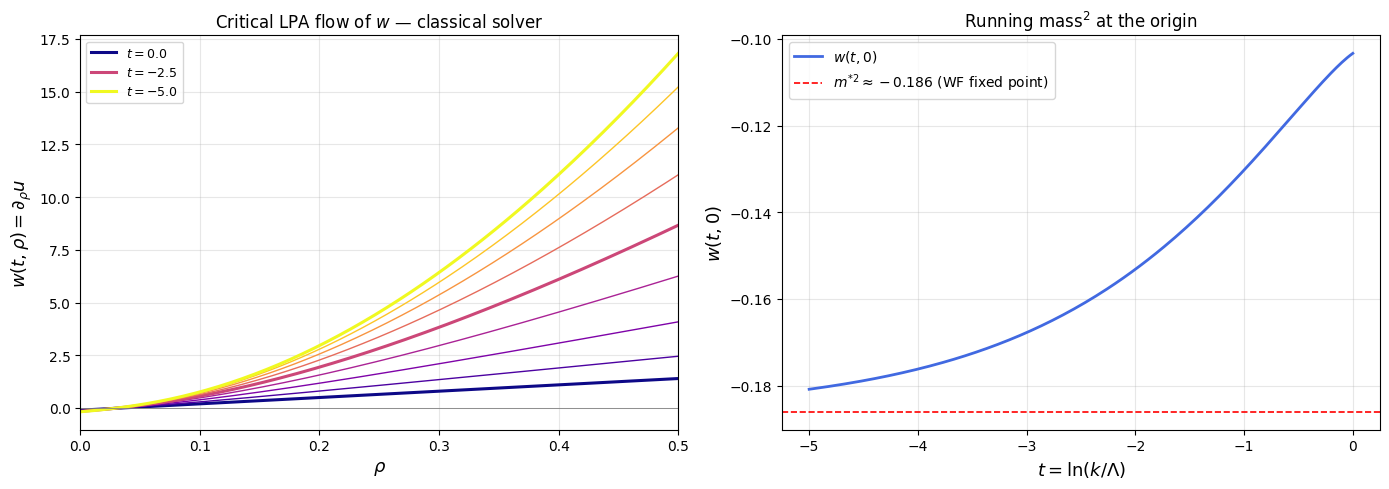

IR minimum at t=-5.0: rho_min = 0.0309  (WF fixed point: rho* ~ 0.031)


In [3]:
t_slices = np.linspace(T_UV, T_IR, 9)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cmap = plt.cm.plasma

for i, t_val in enumerate(t_slices):
    c  = cmap(i / (len(t_slices) - 1))
    lw = 2.2 if i in (0, len(t_slices)//2, len(t_slices)-1) else 1.0
    label = f"$t={t_val:.1f}$" if i in (0, len(t_slices)//2, len(t_slices)-1) else None
    axes[0].plot(rho, w_cl(t_val), color=c, lw=lw, label=label)

axes[0].axhline(0, color="gray", lw=0.6)
axes[0].set_xlabel(r"$\rho$", fontsize=13)
axes[0].set_ylabel(r"$w(t,\rho)=\partial_\rho u$", fontsize=13)
axes[0].set_title("Critical LPA flow of $w$ — classical solver", fontsize=12)
axes[0].set_xlim(0, RHO_MAX)
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# Running mass^2 at the origin flows into the WF fixed-point value m*^2 (Sec. 2)
t_dense = np.linspace(T_UV, T_IR, 200)
w0_vals = w_cl(t_dense)[0]
axes[1].plot(t_dense, w0_vals, lw=2, color="royalblue", label=r"$w(t,0)$")
axes[1].axhline(-0.18606, ls="--", color="red", lw=1.2,
                label=r"$m^{*2}\approx-0.186$ (WF fixed point)")
axes[1].set_xlabel(r"$t = \ln(k/\Lambda)$", fontsize=13)
axes[1].set_ylabel(r"$w(t,0)$", fontsize=13)
axes[1].set_title(r"Running mass$^2$ at the origin", fontsize=12)
axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("frg_classical.png", dpi=130, bbox_inches="tight")
plt.show()

# potential minimum = zero crossing of w
w_ir = w_cl(T_IR)
j = np.where(np.diff(np.sign(w_ir)))[0][0]
rho_min_ir = rho[j] - w_ir[j]*drho/(w_ir[j+1] - w_ir[j])
print(f"IR minimum at t={T_IR}: rho_min = {rho_min_ir:.4f}  (WF fixed point: rho* ~ 0.031)")

## 2. Wilson–Fisher Fixed Point (Reference ODE)

Setting $\partial_t u^*=0$ gives a **nonlinear 2nd-order ODE** in $\rho$:
$$-3u^* + \rho(u^*)' + \frac{C}{1+(u^*)'+ 2\rho(u^*)''}=0$$

We solve it by **shooting from $\rho=0$** using the regularity expansion:
$$u^*(0)=\frac{C}{3(1+m^{*2})}, \quad (u^*)'(0)=m^{*2}, \quad (u^*)''(0)=-\frac{2m^{*2}(1+m^{*2})^2}{3C}$$

The shooting parameter $m^{*2}\equiv(u^*)'(0)$ is found by requiring the solution to be **globally regular** (no Landau pole). The Wilson–Fisher fixed point lies at the separatrix.

| Quantity | LPA ($\eta=0$) | Monte Carlo |
|----------|------------|-------------|
| $\nu$ | **0.6491** | 0.6304 |
| $\eta$ | 0 (LPA) | 0.0362 |

*Berges, Tetradis, Wetterich 2002; Hasenbusch, PRB 82 (2010)*


WF shooting parameter : m*^2 = -0.18606
Fixed-point at origin : u*(0) = 0.00692
Potential minimum     : rho*  = 0.0309
Solution survives to  : rho   = 2.0724  (target 6.0)
Known LPA exponent    : nu_LPA = 0.6491


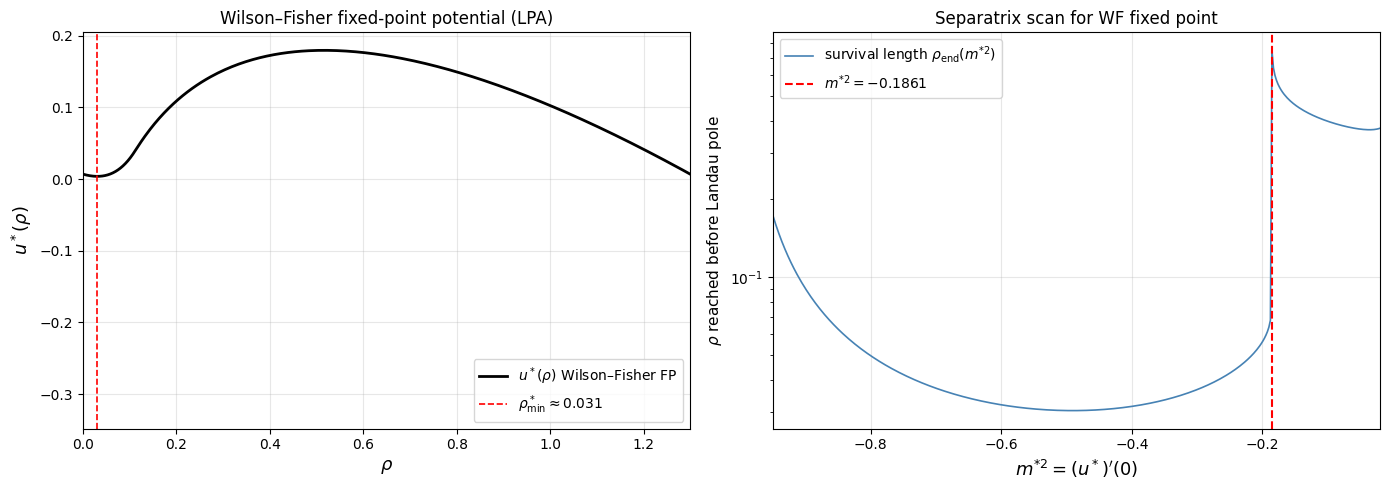

In [4]:
EPS0 = 1e-4   # start integration just off rho=0

def fp_ic(m2):
    """Series-expansion ICs at rho=EPS0 from shooting parameter m2=u'(0)."""
    u0   = C_LPA / (3.0 * (1.0 + m2))
    u2   = -2.0 * m2 * (1.0 + m2)**2 / (3.0 * C_LPA)  # u''(0) coefficient
    u_e  = u0 + m2*EPS0 + 0.5*u2*EPS0**2
    up_e = m2 + u2*EPS0
    return u_e, up_e

def fp_ode(rho, y):
    """RHS of fixed-point ODE written as first-order system [u, u']."""
    u, up  = y
    denom3 = 3.0*u - rho*up         # = C / threshold_denom  (must stay > 0)
    denom3 = max(denom3, 1e-9)
    u_pp   = (C_LPA/denom3 - 1.0 - up) / (2.0*rho)
    return [up, u_pp]

def landau_event(rho, y):
    return 3.0*y[0] - rho*y[1] - 1e-6   # triggers when denominator -> 0

landau_event.terminal  = True
landau_event.direction = -1

def shoot(m2, rho_max=6.0):
    u_e, up_e = fp_ic(m2)
    return solve_ivp(fp_ode, [EPS0, rho_max], [u_e, up_e],
                     events=landau_event, method="RK45",
                     dense_output=True, max_step=0.005, rtol=1e-9, atol=1e-11)

def rho_reached(m2, rho_cap):
    """How far in rho the trial trajectory survives before hitting the Landau pole."""
    if 1.0 + m2 <= 0:
        return 0.0
    return shoot(m2, rho_max=rho_cap).t[-1]

# ── Locate the separatrix ────────────────────────────────────────────────────
# Every trial m2 eventually hits the Landau pole at some finite rho, but the
# survival distance peaks sharply right at the true WF fixed point. Instead we
# locate the peak with a coarse scan, then maximize the survival distance
# directly via golden-section search, tightening the target as we converge.
m2_scan = np.linspace(-0.95, -0.02, 400)
t_ends  = np.array([rho_reached(m2, 2.0) for m2 in m2_scan])
i_peak  = np.argmax(t_ends)
lo, hi  = m2_scan[max(i_peak - 1, 0)], m2_scan[min(i_peak + 1, len(m2_scan) - 1)]

rho_cap = 2.0
for it in range(60):
    m2_a = lo + (hi - lo) / 3
    m2_b = hi - (hi - lo) / 3
    if rho_reached(m2_a, rho_cap) < rho_reached(m2_b, rho_cap):
        lo = m2_a
    else:
        hi = m2_b
    if it % 8 == 7:
        rho_cap = min(rho_cap * 1.6, 6.0)

m2_wf = 0.5 * (lo + hi)

sol_wf  = shoot(m2_wf, rho_max=6.0)
rho_wf  = sol_wf.t
u_wf    = sol_wf.y[0]
up_wf   = sol_wf.y[1]
kap_star = rho_wf[np.argmin(np.abs(up_wf))]

print(f"WF shooting parameter : m*^2 = {m2_wf:.5f}")
print(f"Fixed-point at origin : u*(0) = {C_LPA/(3*(1+m2_wf)):.5f}")
print(f"Potential minimum     : rho*  = {kap_star:.4f}")
print(f"Solution survives to  : rho   = {rho_wf[-1]:.4f}  (target 6.0)")
print(f"Known LPA exponent    : nu_LPA = 0.6491")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rho_wf, u_wf, "k-", lw=2, label=r"$u^*(\rho)$ Wilson–Fisher FP")
axes[0].axvline(kap_star, ls="--", color="red", lw=1.2,
                label=rf"$\rho^*_{{\min}}\approx{kap_star:.3f}$")
axes[0].set_xlabel(r"$\rho$", fontsize=13); axes[0].set_ylabel(r"$u^*(\rho)$", fontsize=13)
axes[0].set_title("Wilson–Fisher fixed-point potential (LPA)", fontsize=12)
axes[0].set_xlim(0, 1.3); axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3)

axes[1].semilogy(m2_scan, np.maximum(t_ends, 1e-3), color="steelblue", lw=1.2,
                  label=r"survival length $\rho_\mathrm{end}(m^{*2})$")
axes[1].axvline(m2_wf, ls="--", color="red", lw=1.5,
                label=rf"$m^{{*2}}={m2_wf:.4f}$")
axes[1].set_xlim(m2_scan[0], m2_scan[-1])
axes[1].set_xlabel(r"$m^{*2}=(u^*)'(0)$", fontsize=13)
axes[1].set_ylabel(r"$\rho$ reached before Landau pole", fontsize=11)
axes[1].set_title("Separatrix scan for WF fixed point", fontsize=12)
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("frg_fixedpoint.png", dpi=130, bbox_inches="tight")
plt.show()


## 3. Physics-Informed Neural Network (PINN)

We train $w_\theta(t,\rho)$ to satisfy the $w$-flow on $(t,\rho)\in[T_\mathrm{IR},0]\times[0,\rho_\mathrm{max}]$.

### Hard initial-condition encoding
$$w_\theta(t,\rho) = w_\mathrm{UV}(\rho) + (-t)\cdot s\,\mathcal{N}_\theta(t,\rho), \qquad w_\mathrm{UV}(\rho)=\lambda(\rho-\kappa_c)$$
which guarantees $w_\theta(0,\rho)=w_\mathrm{UV}(\rho)$ for any network $\mathcal{N}_\theta$ ($s=4$ is a fixed output scale so the tanh network works with $O(1)$ values).

### Training objective
Weighted PDE residual, with derivatives from **automatic differentiation**:
$$\mathcal{L} = \frac{1}{N}\sum_{i=1}^N \omega_i^2\left[\partial_t w_\theta + 2w_\theta - \rho_i\,\partial_\rho w_\theta + \frac{C\,(3\partial_\rho w_\theta + 2\rho_i\partial_\rho^2 w_\theta)}{(1+w_\theta+2\rho_i\,\partial_\rho w_\theta)^2}\right]^2,\qquad \omega_i=\frac{1}{1+|w_\theta|}$$

The weight $\omega_i$ balances the residual scale across the domain ($w$ ranges from $\sim-0.2$ near the origin to $\sim 17$ at the outer boundary in the IR).

### Two tricks that matter for RG flows
1. **Time-marching curriculum**: collocation points are sampled from an expanding window $t\in[t_\mathrm{lo}(\mathrm{epoch}),0]$. Residual errors made early in $t$ are amplified exponentially ($\sim e^{2|t|}$) along the flow, so the network must learn the flow *causally*, from the UV toward the IR.
2. **LBFGS polish**: after Adam, a full-batch LBFGS stage sharpens the solution (standard PINN practice).

In [5]:
class WetterichNet(nn.Module):
    """MLP for w = du/drho with hard UV initial-condition encoding."""

    def __init__(self, hidden=64, depth=4, out_scale=4.0):
        super().__init__()
        self.register_buffer("t_min",   torch.tensor(T_IR,    dtype=torch.float32))
        self.register_buffer("t_max",   torch.tensor(T_UV,    dtype=torch.float32))
        self.register_buffer("rho_max", torch.tensor(RHO_MAX, dtype=torch.float32))
        self.register_buffer("lam",     torch.tensor(LAM_UV,  dtype=torch.float32))
        self.register_buffer("kap",     torch.tensor(KAP_C,   dtype=torch.float32))
        self.out_scale = out_scale

        layers = [nn.Linear(2, hidden), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers += [nn.Linear(hidden, 1)]
        self.net = nn.Sequential(*layers)

    def _normalize(self, t, rho):
        t_n   = 2*(t   - self.t_min)  / (self.t_max   - self.t_min)   - 1
        rho_n = 2* rho / self.rho_max - 1
        return torch.stack([t_n, rho_n], dim=-1)

    def w_uv(self, rho):
        return self.lam * (rho - self.kap)

    def forward(self, t, rho):
        x      = self._normalize(t, rho)
        nn_out = self.net(x).squeeze(-1)
        return self.w_uv(rho) + (-t) * self.out_scale * nn_out


model = WetterichNet().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Network: depth=4, hidden=64, tanh  |  {n_params:,} parameters")
print(model.net)

Network: depth=4, hidden=64, tanh  |  12,737 parameters
Sequential(
  (0): Linear(in_features=2, out_features=64, bias=True)
  (1): Tanh()
  (2): Linear(in_features=64, out_features=64, bias=True)
  (3): Tanh()
  (4): Linear(in_features=64, out_features=64, bias=True)
  (5): Tanh()
  (6): Linear(in_features=64, out_features=64, bias=True)
  (7): Tanh()
  (8): Linear(in_features=64, out_features=1, bias=True)
)


Training PINN: 10000 Adam epochs (1024 collocation pts/epoch)...
  Epoch  2000/10000  window t>-1.93  loss=4.6654e-05
  Epoch  4000/10000  window t>-3.36  loss=1.8915e-04
  Epoch  6000/10000  window t>-4.79  loss=5.3523e-05
  Epoch  8000/10000  window t>-5.00  loss=2.2172e-05
  Epoch 10000/10000  window t>-5.00  loss=1.0649e-05
LBFGS polish...
Final loss: 1.4163e-05


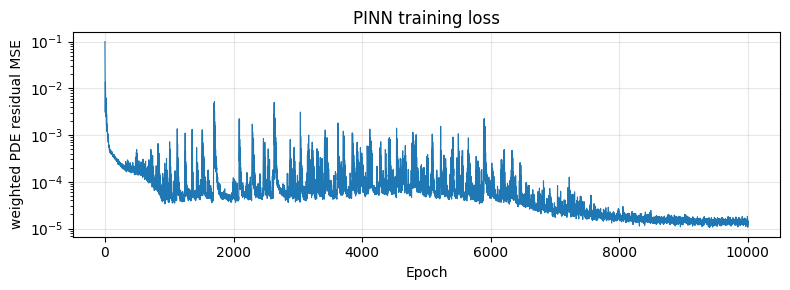

In [6]:
C_T = torch.tensor(C_LPA, dtype=torch.float32, device=DEVICE)

def pde_residual(net, t, rho):
    t   = t.detach().requires_grad_(True)
    rho = rho.detach().requires_grad_(True)

    w    = net(t, rho)
    w_t  = torch.autograd.grad(w.sum(), t,   create_graph=True)[0]
    w_r  = torch.autograd.grad(w.sum(), rho, create_graph=True)[0]
    w_rr = torch.autograd.grad(w_r.sum(), rho, create_graph=True)[0]

    denom = torch.clamp(1.0 + w + 2.0*rho*w_r, min=DENOM_MIN)
    rhs   = -2.0*w + rho*w_r - C_T*(3.0*w_r + 2.0*rho*w_rr)/denom**2
    return w_t - rhs

def rel_weight(net, t, rho):
    """1/(1+|w|): balances the residual scale across the domain."""
    with torch.no_grad():
        return 1.0 / (1.0 + net(t, rho).abs())

N_EPOCHS = 10000
N_COL    = 1024

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, N_EPOCHS, eta_min=1e-5)

losses = []
print(f"Training PINN: {N_EPOCHS} Adam epochs ({N_COL} collocation pts/epoch)...")
for epoch in range(N_EPOCHS):
    # curriculum: expand the t-window from the UV toward the IR (causal training)
    frac  = min(1.0, 0.1 + (epoch + 1) / (0.7 * N_EPOCHS))
    t_lo  = T_UV + frac * (T_IR - T_UV)
    t_c   = torch.empty(N_COL, device=DEVICE).uniform_(t_lo, T_UV)
    rho_c = torch.empty(N_COL, device=DEVICE).uniform_(0.0, RHO_MAX)

    optimizer.zero_grad()
    res  = pde_residual(model, t_c, rho_c)
    wgt  = rel_weight(model, t_c, rho_c)
    loss = ((wgt * res)**2).mean()
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    scheduler.step()
    losses.append(loss.item())
    if (epoch + 1) % 2000 == 0:
        print(f"  Epoch {epoch+1:5d}/{N_EPOCHS}  window t>{t_lo:5.2f}  loss={loss.item():.4e}")

# ── LBFGS polish on a fixed dense collocation set ─────────────────────────────
t_f   = torch.empty(8192, device=DEVICE).uniform_(T_IR, T_UV)
rho_f = torch.empty(8192, device=DEVICE).uniform_(0.0, RHO_MAX)
lbfgs = torch.optim.LBFGS(model.parameters(), max_iter=500, history_size=50,
                          tolerance_grad=1e-10, tolerance_change=1e-12,
                          line_search_fn="strong_wolfe")

def closure():
    lbfgs.zero_grad()
    res = pde_residual(model, t_f, rho_f)
    wgt = rel_weight(model, t_f, rho_f)
    l   = ((wgt * res)**2).mean()
    l.backward()
    return l

print("LBFGS polish...")
loss_f = lbfgs.step(closure)
losses.append(loss_f.item())
print(f"Final loss: {loss_f.item():.4e}")

plt.figure(figsize=(8, 3))
plt.semilogy(losses, lw=0.8)
plt.xlabel("Epoch"); plt.ylabel("weighted PDE residual MSE")
plt.title("PINN training loss"); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("frg_pinn_loss.png", dpi=120, bbox_inches="tight")
plt.show()

MAE  (PINN vs classical): 1.1389e-01
Max  absolute error     : 8.6784e-01
Relative MAE            : 3.4764e-02


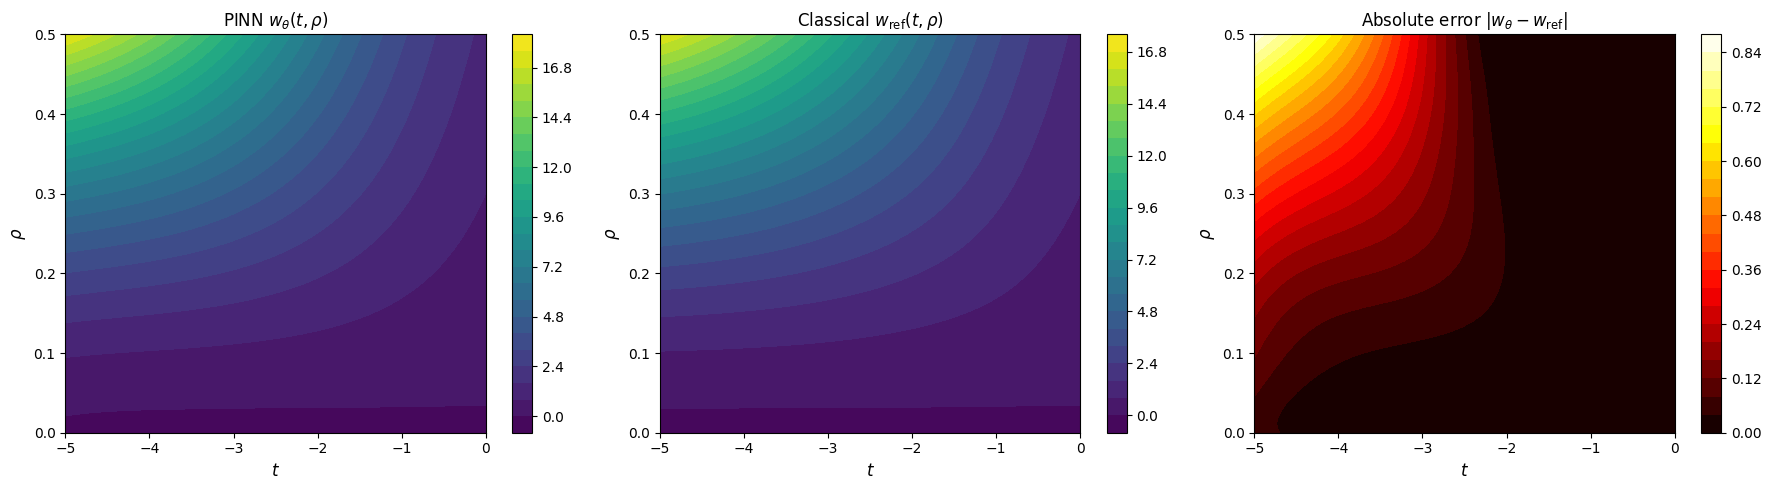

In [7]:
model.eval()

N_T, N_R = 40, 80
t_grid   = np.linspace(T_UV, T_IR, N_T)
rho_grid = np.linspace(0.0, RHO_MAX, N_R)
T_mesh, R_mesh = np.meshgrid(t_grid, rho_grid, indexing="ij")   # (N_T, N_R)

# PINN predictions
T_flat = torch.tensor(T_mesh.ravel(), dtype=torch.float32, device=DEVICE)
R_flat = torch.tensor(R_mesh.ravel(), dtype=torch.float32, device=DEVICE)
with torch.no_grad():
    w_pinn = model(T_flat, R_flat).cpu().numpy().reshape(N_T, N_R)

# Classical reference interpolated onto (t_grid, rho_grid)
w_ref = np.stack([interp1d(rho, w_cl(tt), kind="cubic")(rho_grid) for tt in t_grid])

err = np.abs(w_pinn - w_ref)
mae     = err.mean()
max_err = err.max()
rel_err = mae / (np.abs(w_ref).mean() + 1e-12)
print(f"MAE  (PINN vs classical): {mae:.4e}")
print(f"Max  absolute error     : {max_err:.4e}")
print(f"Relative MAE            : {rel_err:.4e}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
kw = dict(levels=25, cmap="viridis")

cf1 = axes[0].contourf(T_mesh, R_mesh, w_pinn, **kw)
axes[0].set_title(r"PINN $w_\theta(t,\rho)$", fontsize=12)
plt.colorbar(cf1, ax=axes[0])

cf2 = axes[1].contourf(T_mesh, R_mesh, w_ref, **kw)
axes[1].set_title(r"Classical $w_\mathrm{ref}(t,\rho)$", fontsize=12)
plt.colorbar(cf2, ax=axes[1])

cf3 = axes[2].contourf(T_mesh, R_mesh, err, levels=25, cmap="hot")
axes[2].set_title(r"Absolute error $|w_\theta - w_\mathrm{ref}|$", fontsize=12)
plt.colorbar(cf3, ax=axes[2])

for ax in axes:
    ax.set_xlabel(r"$t$", fontsize=12)
    ax.set_ylabel(r"$\rho$", fontsize=12)

plt.tight_layout()
plt.savefig("frg_comparison.png", dpi=130, bbox_inches="tight")
plt.show()

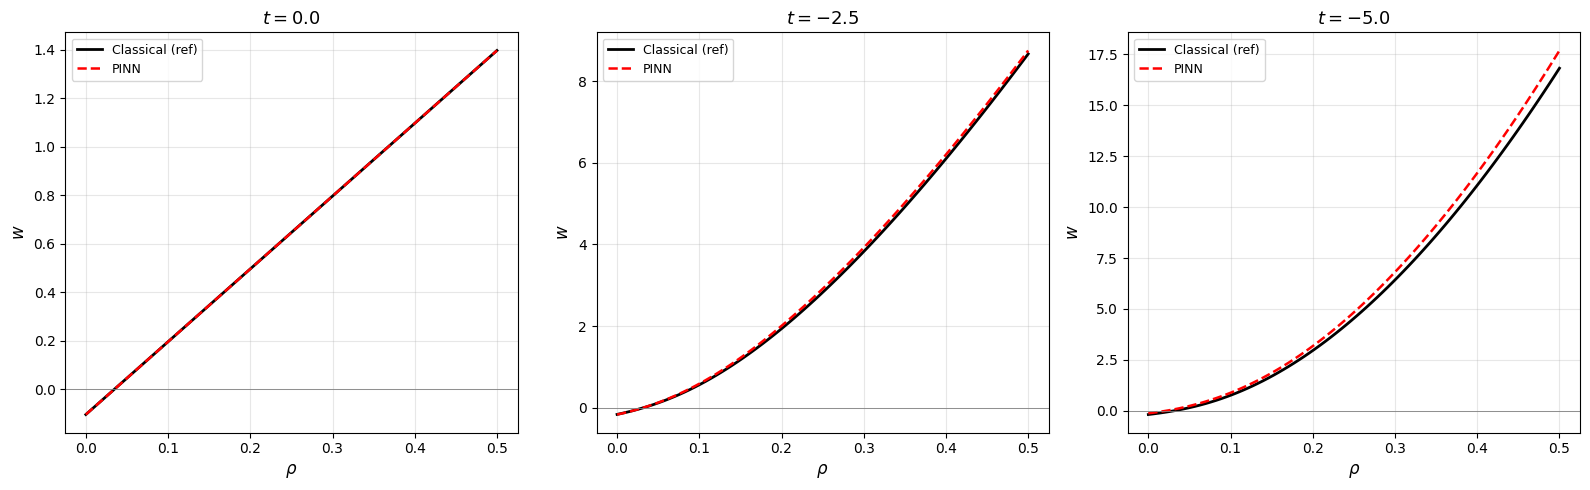

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, t_check in zip(axes, [0.0, -2.5, -5.0]):
    w_cl_rg = interp1d(rho, w_cl(t_check), kind="cubic")(rho_grid)

    t_t = torch.full((N_R,), t_check, dtype=torch.float32, device=DEVICE)
    r_t = torch.tensor(rho_grid, dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        w_pn = model(t_t, r_t).cpu().numpy()

    ax.plot(rho_grid, w_cl_rg, "k-",  lw=2,   label="Classical (ref)")
    ax.plot(rho_grid, w_pn,    "r--", lw=1.8, label="PINN")
    ax.axhline(0, color="gray", lw=0.6)
    ax.set_xlabel(r"$\rho$", fontsize=12)
    ax.set_ylabel(r"$w$", fontsize=12)
    ax.set_title(f"$t = {t_check}$", fontsize=13)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("frg_slices.png", dpi=130, bbox_inches="tight")
plt.show()

## Summary

| Ground-truth reference | Method | What it checks |
|------------------------|--------|---------------|
| Classical LSODA+FD ($w$-flow) | `scipy.integrate.solve_ivp` | Full $(t,\rho)$ trajectory |
| Wilson–Fisher FP | Separatrix shooting | Fixed-point structure, $\nu$ |
| $\nu_\mathrm{LPA}=0.6491$ | Linearised stability at FP | Critical exponent |

### What made the PINN work
- **Flow $w=\partial_\rho u$, not $u$**: removes the $-3u$ volume term whose $e^{-3t}$ growth no bounded network can represent.
- **Tune to criticality**: only the critical trajectory stays bounded and pole-free on the whole $(t,\rho)$ domain (symmetric phase: $w\sim e^{-2t}$; broken phase: Landau pole at finite $t$).
- **Small $\rho$-domain**, residual weighting $1/(1+|w|)$, time-marching curriculum, LBFGS polish.

### Beyond LPA
- **LPA'**: include running wavefunction renormalisation $Z_k\ne 1$ → $\eta\ne 0$, $\nu$ improves.
- **BMW / DE**: derivative expansion to order $\partial^4$, approaching exact results.
- **$N$-component fields**: threshold function gets a Goldstone contribution $(N-1)\times 1/(1+u_\rho')$.

### Key references
1. C. Wetterich, *Exact evolution equation for the effective potential*, Phys. Lett. B **301** (1993) 90
2. J. Berges, N. Tetradis, C. Wetterich, Phys. Rep. **363** (2002) 223
3. D.F. Litim, Phys. Rev. D **64** (2001) 105007
4. B. Delamotte, arXiv:cond-mat/0702365 (2007) — pedagogical review